# 08 · Visual exploration of results

These figures **describe** the results. The conclusions come from the prespecified inference in notebook 06: `primary_result.json`, `comparisons.csv` and `beats_chance.csv`.

In synthetic mode, the notebook generates a small demonstration run so every figure can be previewed. With `USE_REAL_DATA = True`, it reads the saved results and also writes the figures to `results/figures/`.

In [1]:
from pathlib import Path
from functools import partial
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
NOTEBOOKS = ROOT / "notebooks"
RESULTS = ROOT / "results"
FIGURES = RESULTS / "figures"


def use_notebook(name):
    """Run the definition cells (tagged "library") of another notebook in this namespace."""
    notebook = json.loads((NOTEBOOKS / name).read_text(encoding="utf-8"))
    for cell in notebook["cells"]:
        if cell["cell_type"] == "code" and "library" in cell["metadata"].get("tags", []):
            exec("".join(cell["source"]), globals())


def load_yaml(path):
    with open(path, encoding="utf-8") as fh:
        return yaml.safe_load(fh)

In [2]:
use_notebook("07_stability_and_confounds.ipynb")   # stability + everything from notebooks 04-06

In [3]:
USE_REAL_DATA = False
MODELS = ["structural", "functional", "early_fusion", "equal_weight", "mkl", "stacking"]

if USE_REAL_DATA:
    predictions = pd.read_csv(RESULTS / "predictions" / "predictions.csv")
    selections = pd.read_csv(RESULTS / "metrics" / "selections.csv")
else:
    X, y, blocks = make_synthetic(n=100, p_s=30, p_f=300, signal="both", effect=0.6, seed=4)
    ids = np.array([f"sub-{i:03d}" for i in range(len(y))])
    cfg = demo_config(beta_grid=[round(b, 1) for b in np.linspace(0, 1, 11)])
    predictions, selections, _ = run_nested_cv(X, y, ids, partial(build_models, cfg, blocks, include=MODELS),
                                               seeds=[11, 23, 37, 41, 53], n_outer=5, n_inner=3, n_jobs=-1)
folds = fold_metrics(predictions)


def save(fig, name):
    if USE_REAL_DATA:
        FIGURES.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIGURES / name, dpi=150, bbox_inches="tight")

## Figure 1: outer-fold AUC per model
- **What is plotted:** each box shows the distribution of AUC across outer folds (5 repeats × 5 folds in the preview; 50 folds in the real analysis).
- **How to read the spread:** it shows how much performance depends on the partition. It is not a confidence interval.
- **Reference line:** the dashed line marks chance (0.5).

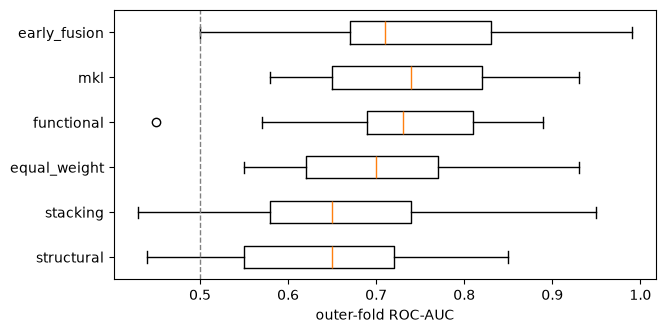

,model,auc_mean,auc_std,pr_auc_mean,pr_auc_std,balanced_accuracy_mean,balanced_accuracy_std,sensitivity_mean,sensitivity_std,specificity_mean,specificity_std,prevalence_mean,prevalence_std
0,structural,0.638,0.109,0.671,0.110,0.562,0.082,0.600,0.333,0.524,0.348,0.5,0.0
1,functional,0.737,0.100,0.787,0.082,0.590,0.105,0.560,0.349,0.620,0.367,0.5,0.0
2,early_fusion,0.749,0.115,0.798,0.089,0.628,0.102,0.644,0.306,0.612,0.347,0.5,0.0
3,equal_weight,0.709,0.110,0.739,0.114,0.592,0.110,0.576,0.356,0.608,0.357,0.5,0.0
4,mkl,0.740,0.105,0.788,0.086,0.576,0.093,0.620,0.362,0.532,0.379,0.5,0.0
5,stacking,0.661,0.139,0.708,0.130,0.598,0.097,0.648,0.250,0.548,0.282,0.5,0.0


In [4]:
order = folds.groupby("model")["auc"].mean().sort_values().index
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.boxplot([folds.loc[folds["model"] == m, "auc"] for m in order], orientation="horizontal")
ax.set_yticks(range(1, len(order) + 1), order)
ax.axvline(0.5, color="grey", lw=1, ls="--")
ax.set_xlabel("outer-fold ROC-AUC")
save(fig, "auc_by_model.png")
plt.show()
display(summarize(folds).round(3))

## Figure 2: the paired ΔAUC, MKL − functional (the primary comparison)
- **What is plotted:** one value per outer fold, each computed on the same test participants for both models.
- **Reference lines:** the solid line at 0 means no difference; the dashed line marks the minimum meaningful difference δ = 0.02.
- **The formal decision** comes from the corrected CI and the structural-block permutation p-value (notebook 06).

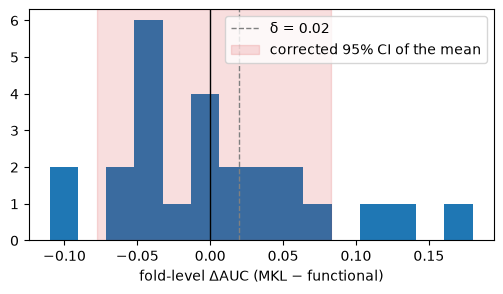

mean ΔAUC = 0.003, corrected 95% CI [-0.077, 0.083]


In [5]:
wide = folds.pivot_table(index=["repeat", "fold"], columns="model", values="auc")
delta_folds = wide["mkl"] - wide["functional"]
ci = corrected_resampled_ci(delta_folds.to_numpy(), test_train_ratio=0.25)
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(delta_folds, bins=15)
ax.axvline(0, color="k", lw=1)
ax.axvline(0.02, color="grey", ls="--", lw=1, label="δ = 0.02")
ax.axvspan(ci["ci_low"], ci["ci_high"], color="tab:red", alpha=0.15, label="corrected 95% CI of the mean")
ax.set_xlabel("fold-level ΔAUC (MKL − functional)")
ax.legend()
save(fig, "paired_delta_auc.png")
plt.show()
print(f"mean ΔAUC = {ci['mean']:.3f}, corrected 95% CI [{ci['ci_low']:.3f}, {ci['ci_high']:.3f}]")

## Figure 3: how much weight each model gives the structural kernel
- **MKL:** the β_s selected in each outer fold. If it piles up at 0, MKL effectively reduced to the functional model.
- **Early fusion:** the implicit weight p_s/(p_s+p_f), which is fixed by the feature counts (≈ 0.03 at COBRE size).

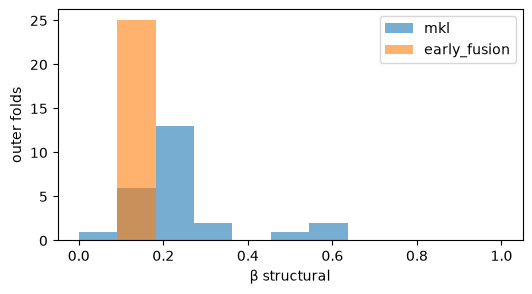

share of folds with β_s = 0 (MKL = functional model): 0.04


In [6]:
fig, ax = plt.subplots(figsize=(6, 3))
for model in ["mkl", "early_fusion"]:
    ax.hist(selections.loc[selections["model"] == model, "beta_structural"], bins=11, range=(0, 1), alpha=0.6, label=model)
ax.set_xlabel("β structural")
ax.set_ylabel("outer folds")
ax.legend()
save(fig, "beta_structural.png")
plt.show()
print("share of folds with β_s = 0 (MKL = functional model):",
      round(float((selections.loc[selections["model"] == "mkl", "beta_structural"] == 0).mean()), 2))

## Figure 4: prediction stability of MKL
- **What is plotted:** each dot is one participant, showing the mean of their out-of-sample scores against the SD across repeats.
- **How to read it:**
  - points far from 0 on the x-axis are classified confidently;
  - points high on the y-axis are unstable, meaning their prediction depends on the training partition.

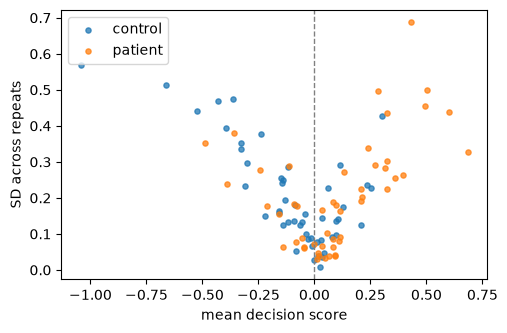

In [7]:
stability = prediction_stability(predictions, "mkl")
fig, ax = plt.subplots(figsize=(5.5, 3.5))
for label, name in [(0, "control"), (1, "patient")]:
    s = stability[stability["y_true"] == label]
    ax.scatter(s["mean_score"], s["sd_score"], s=14, alpha=0.75, label=name)
ax.axvline(0, color="grey", lw=1, ls="--")
ax.set_xlabel("mean decision score")
ax.set_ylabel("SD across repeats")
ax.legend()
save(fig, "prediction_stability_mkl.png")
plt.show()

## Figure 5: PR-AUC against its chance level
PR-AUC must be compared with the prevalence of patients in the test fold, not with 0.5. The dotted line marks that chance level.

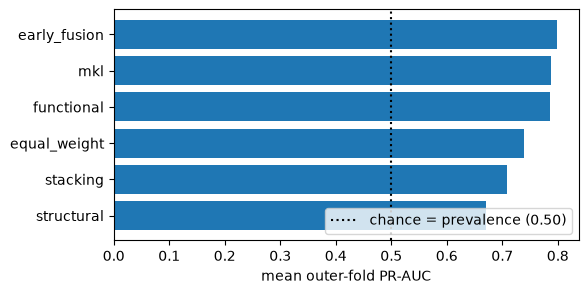

In [8]:
pr = folds.groupby("model")[["pr_auc", "prevalence"]].mean().loc[order]
fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(pr.index, pr["pr_auc"])
ax.axvline(pr["prevalence"].mean(), color="k", ls=":", label=f"chance = prevalence ({pr['prevalence'].mean():.2f})")
ax.set_xlabel("mean outer-fold PR-AUC")
ax.legend(loc="lower right")
save(fig, "pr_auc_by_model.png")
plt.show()